In [22]:
import pandas as pd
import unicodedata
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout, AdditiveAttention, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Function to normalize text data
def unicode_normalization(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

# Load the dataset
data = pd.read_csv('/content/english_french.csv')  # Update the path as needed
data['English'] = data['English'].apply(unicode_normalization)
data['French'] = data['French'].apply(unicode_normalization)

# Calculate sentence lengths
data['English_len'] = data['English'].apply(lambda x: len(x.split()))
data['French_len'] = data['French'].apply(lambda x: len(x.split()))

# Remove sentences longer than the 95th percentile length
threshold_english = data['English_len'].quantile(0.95)
threshold_french = data['French_len'].quantile(0.95)
data = data[(data['English_len'] <= threshold_english) & (data['French_len'] <= threshold_french)]

# Shuffle the data
data = data.sample(frac=1).reset_index(drop=True)

# Tokenize the sentences
tokenizer_eng = Tokenizer()
tokenizer_eng.fit_on_texts(data['English'])

tokenizer_fra = Tokenizer()
tokenizer_fra.fit_on_texts(data['French'])

# Convert sentences to sequences of integers
english_sequences = tokenizer_eng.texts_to_sequences(data['English'])
french_sequences = tokenizer_fra.texts_to_sequences(data['French'])

# Find the maximum sequence length for padding
max_length_eng = max([len(seq) for seq in english_sequences])
max_length_fra = max([len(seq) for seq in french_sequences])

# Pad sequences to the maximum length
english_padded = pad_sequences(english_sequences, maxlen=max_length_eng, padding='post')
french_padded = pad_sequences(french_sequences, maxlen=max_length_fra, padding='post')

# Prepare the training data
encoder_input_data = english_padded
decoder_input_data = french_padded[:, :-1]  # All but last token
decoder_target_data = french_padded[:, 1:]  # All but first token

# Split the data into training and validation sets using train_test_split
encoder_input_data_train, encoder_input_data_val, decoder_input_data_train, decoder_input_data_val, decoder_target_data_train, decoder_target_data_val = train_test_split(
    encoder_input_data, decoder_input_data, decoder_target_data, test_size=0.2, random_state=42, shuffle=True)


In [23]:
# Model parameters
embedding_dim = 256
lstm_units = 256
l2_lambda = 1e-4  # Regularization factor
dropout_rate = 0.5

# Encoder
encoder_inputs = Input(shape=(None,))
encoder_embedding = Embedding(input_dim=len(tokenizer_eng.word_index) + 1, output_dim=embedding_dim)(encoder_inputs)
encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate, recurrent_regularizer=l2(l2_lambda))
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder with attention
decoder_inputs = Input(shape=(None,))
decoder_embedding = Embedding(input_dim=len(tokenizer_fra.word_index) + 1, output_dim=embedding_dim)(decoder_inputs)
decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate, recurrent_regularizer=l2(l2_lambda))
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# Attention layer
attention = AdditiveAttention()
context_vector = attention([decoder_outputs, encoder_outputs])
decoder_combined_context = Concatenate(axis=-1)([context_vector, decoder_outputs])

# Output layer
decoder_dense = Dense(len(tokenizer_fra.word_index) + 1, activation='softmax', kernel_regularizer=l2(l2_lambda))
decoder_outputs = decoder_dense(decoder_combined_context)

# Define the complete model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_4 (Embedding)   │ (None, None, 256)      │      4,001,792 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_5 (Embedding)   │ (None, None, 256)      │      7,121,152 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_4 (LSTM)             │ [(None, None, 256),    │        525,312 │ embedding_4[0][0]      │
│                           │ (None, 256), (None,    │                │                        │
│                           │ 256)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_5 (LSTM)             │ [(None, None, 256),    │        525,312 │ embedding_5[0][0],     │
│                           │ (None, 256), (None,    │                │ lstm_4[0][1],          │
│                           │ 256)]                  │                │ lstm_4[0][2]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ additive_attention_1      │ (None, None, 256)      │            256 │ lstm_5[0][0],          │
│ (AdditiveAttention)       │                        │                │ lstm_4[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, None, 512)      │              0 │ additive_attention_1[… │
│ (Concatenate)             │                        │                │ lstm_5[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, None, 27817)    │     14,270,121 │ concatenate_1[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 26,443,945 (100.88 MB)

 Trainable params: 26,443,945 (100.88 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Directory for saving model checkpoints
checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")  # Save weights only

# Callbacks
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_prefix, save_weights_only=True, save_best_only=True, monitor='val_loss', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    [encoder_input_data_train, decoder_input_data_train], decoder_target_data_train,
    batch_size=64,
    epochs=35,
    validation_data=([encoder_input_data_val, decoder_input_data_val], decoder_target_data_val),
    callbacks=[early_stopping, checkpoint_callback],
    shuffle=True  # Shuffle data at the beginning of each epoch
)

# Save the entire model at the end
model.save('trained_translation_model_with_attention.keras')


Epoch 1/35
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6142 - loss: 3.0244
Epoch 1: val_loss improved from inf to 2.38303, saving model to ./training_checkpoints/ckpt_1.weights.h5
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 137s 49ms/step - accuracy: 0.6142 - loss: 3.0243 - val_accuracy: 0.6577 - val_loss: 2.3830
Epoch 2/35
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6700 - loss: 2.2833
Epoch 2: val_loss improved from 2.38303 to 2.09064, saving model to ./training_checkpoints/ckpt_2.weights.h5
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 134s 49ms/step - accuracy: 0.6700 - loss: 2.2832 - val_accuracy: 0.6977 - val_loss: 2.0906
Epoch 3/35
2742/2743 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7065 - loss: 2.0258
Epoch 3: val_loss improved from 2.09064 to 1.90090, saving model to ./training_checkpoints/ckpt_3.weights.h5
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 134s 49ms/step - accuracy: 0.7065 - loss: 2.0258 - val_accuracy: 0.7274 - val_loss: 1.9009
Epoch 4/35
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 0s

In [26]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate([encoder_input_data_val, decoder_input_data_val], decoder_target_data_val)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Evaluate the model on the training set to check for overfitting
train_loss, train_accuracy = model.evaluate([encoder_input_data_train, decoder_input_data_train], decoder_target_data_train)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")


1372/1372 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8201 - loss: 1.3549
Validation Loss: 1.3489
Validation Accuracy: 0.8213
5486/5486 ━━━━━━━━━━━━━━━━━━━━ 123s 22ms/step - accuracy: 0.8369 - loss: 1.2499
Training Loss: 1.2463
Training Accuracy: 0.8374


In [27]:
# Saving the model
model.save('final_translation_model_with_attention.keras')

# Loading the model
from tensorflow.keras.models import load_model
loaded_model = load_model('final_translation_model_with_attention.keras')


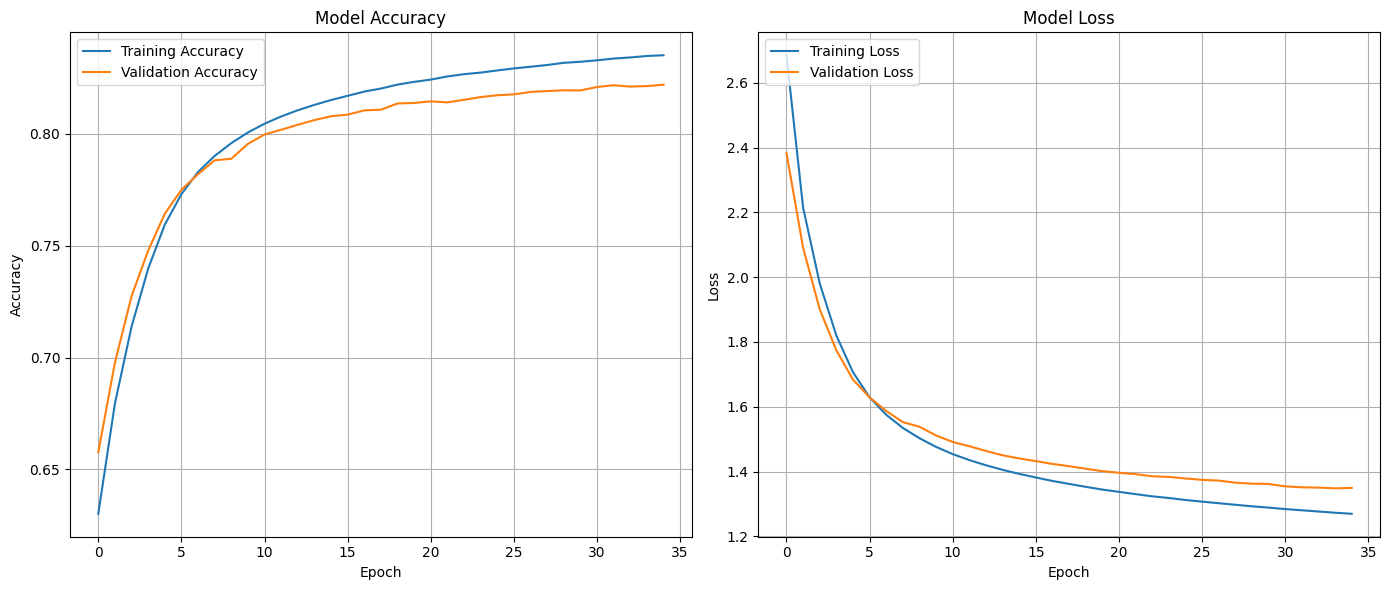

In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


In [29]:
# Convert sequences back to text
def sequence_to_text(sequence, tokenizer):
    reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}
    reverse_word_index[0] = ''  # Padding token is mapped to an empty string
    return ' '.join([reverse_word_index.get(i, '') for i in sequence]).strip()

# Translation function
def translate_sentence(input_sentence, model, tokenizer_eng, tokenizer_fra, max_length_eng, max_length_fra):
    input_sentence = unicode_normalization(input_sentence)
    input_sequence = tokenizer_eng.texts_to_sequences([input_sentence])
    input_padded = pad_sequences(input_sequence, maxlen=max_length_eng, padding='post')

    target_sequence = np.zeros((1, max_length_fra))
    translated_sentence = []

    for i in range(max_length_fra):
        decoder_output = model.predict([input_padded, target_sequence], verbose=0)
        target_word_index = np.argmax(decoder_output[0, i, :])

        if target_word_index == 0:  # Stop at padding or end token
            break

        translated_sentence.append(target_word_index)
        target_sequence[0, i + 1] = target_word_index

    translated_text = sequence_to_text(translated_sentence, tokenizer_fra)
    return translated_text

# Evaluate on a subset of data
num_samples = 10
for i in range(num_samples):
    original_sentence = data['English'].iloc[i]
    reference_translation = data['French'].iloc[i]
    model_translation = translate_sentence(original_sentence, model, tokenizer_eng, tokenizer_fra, max_length_eng, max_length_fra)

    print(f"Original: {original_sentence}")
    print(f"Reference: {reference_translation}")
    print(f"Translated: {model_translation}")
    print("-" * 50)


Original: I'll do it later.
Reference: Je le ferai plus tard.
Translated: je le plus tard
--------------------------------------------------
Original: I think they saw you.
Reference: Je pense qu'ils vous ont apercu.
Translated: qu'ils vous ont vu
--------------------------------------------------
Original: What if they don't like me?
Reference: Qu'en sera-t-il si elles ne m'apprecient pas ?
Translated: 
--------------------------------------------------
Original: You will get the worst beating of your life.
Reference: Vous allez prendre la pire rossee de votre vie.
Translated: ta vie ta vie
--------------------------------------------------
Original: I don't want to live with you anymore.
Reference: Je ne veux plus vivre avec toi.
Translated: ne je veux plus
--------------------------------------------------
Original: He did what I told him to do.
Reference: Il fit ce que je lui dis de faire.
Translated: ce que je lui ai dit
--------------------------------------------------
Original:

In [31]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# You may need to download some resources
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [32]:
def calculate_bleu_score(reference, candidate):
    # Tokenize the sentences
    reference_tokens = nltk.word_tokenize(reference.lower())
    candidate_tokens = nltk.word_tokenize(candidate.lower())

    # Use smoothing function to avoid zero scores in short sentences
    smoothing_function = SmoothingFunction().method4

    # Calculate BLEU score
    bleu_score = sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothing_function)
    return bleu_score


In [33]:
# Evaluate on a subset of data and calculate BLEU scores
num_samples = 10
for i in range(num_samples):
    original_sentence = data['English'].iloc[i]
    reference_translation = data['French'].iloc[i]
    model_translation = translate_sentence(original_sentence, model, tokenizer_eng, tokenizer_fra, max_length_eng, max_length_fra)

    # Calculate BLEU score
    bleu_score = calculate_bleu_score(reference_translation, model_translation)

    print(f"Original: {original_sentence}")
    print(f"Reference: {reference_translation}")
    print(f"Translated: {model_translation}")
    print(f"BLEU Score: {bleu_score:.4f}")
    print("-" * 50)


Original: I'll do it later.
Reference: Je le ferai plus tard.
Translated: plus tard
BLEU Score: 0.0300
--------------------------------------------------
Original: I think they saw you.
Reference: Je pense qu'ils vous ont apercu.
Translated: a qu'ils vous vue
BLEU Score: 0.0795
--------------------------------------------------
Original: What if they don't like me?
Reference: Qu'en sera-t-il si elles ne m'apprecient pas ?
Translated: elles ne me plait
BLEU Score: 0.0619
--------------------------------------------------
Original: You will get the worst beating of your life.
Reference: Vous allez prendre la pire rossee de votre vie.
Translated: ta pire de ta vie
BLEU Score: 0.0221
--------------------------------------------------
Original: I don't want to live with you anymore.
Reference: Je ne veux plus vivre avec toi.
Translated: ne je veux plus
BLEU Score: 0.0736
--------------------------------------------------
Original: He did what I told him to do.
Reference: Il fit ce que je lu

In [36]:
def analyze_bleu_weaknesses(translations):
    for item in translations:
        original = item['original']
        reference = item['reference']
        translated = item['translated']
        bleu_score = item['bleu_score']

        print(f"Original: {original}")
        print(f"Reference: {reference}")
        print(f"Translated: {translated}")
        print(f"BLEU Score: {bleu_score:.4f}")

        # Analyze weaknesses
        if bleu_score < 0.1 and len(translated) > 0:
            print("Weakness: The BLEU score is low, but the translation captures some of the key content or structure.")
            print("Explanation: BLEU heavily penalizes for differences in word order or missing words, even if the translation is partially correct.")

        if bleu_score == 0.0 and len(translated) > 0:
            print("Weakness: The BLEU score is zero despite the translation containing relevant content.")
            print("Explanation: A zero BLEU score can occur if there is no n-gram overlap, even if the translation is relevant but phrased differently.")

        if bleu_score > 0.2 and len(translated.split()) < len(reference.split()):
            print("Weakness: The BLEU score is relatively high, but the translation is incomplete.")
            print("Explanation: BLEU does not account for missing parts of the translation if the existing parts match well with the reference.")

        if len(translated.split()) < len(reference.split()):
            print("Weakness: The translation is significantly shorter than the reference.")
            print("Explanation: BLEU might assign a higher score to shorter translations that match part of the reference well, ignoring missing content.")

        print("-" * 50)


# Example translations and their BLEU scores (from your previous output)
translations = [
    {"original": "I'll do it later.", "reference": "Je le ferai plus tard.", "translated": "plus tard", "bleu_score": 0.0300},
    {"original": "I think they saw you.", "reference": "Je pense qu'ils vous ont apercu.", "translated": "a qu'ils vous vue", "bleu_score": 0.0795},
    {"original": "What if they don't like me?", "reference": "Qu'en sera-t-il si elles ne m'apprecient pas ?", "translated": "elles ne me plait", "bleu_score": 0.0619},
    {"original": "You will get the worst beating of your life.", "reference": "Vous allez prendre la pire rossee de votre vie.", "translated": "ta pire de ta vie", "bleu_score": 0.0221},
    {"original": "I don't want to live with you anymore.", "reference": "Je ne veux plus vivre avec toi.", "translated": "ne je veux plus", "bleu_score": 0.0736},
    {"original": "He did what I told him to do.", "reference": "Il fit ce que je lui dis de faire.", "translated": "a t il dit de faire", "bleu_score": 0.0552},
    {"original": "I'm not worried about Tom.", "reference": "Je ne suis pas inquiet pour Tom.", "translated": "n'est pas tom", "bleu_score": 0.0163},
    {"original": "I've been living here for three years.", "reference": "J'habite ici depuis trois ans.", "translated": "depuis trois ans", "bleu_score": 0.2118},
    {"original": "Keep focused.", "reference": "Restez concentrees.", "translated": "", "bleu_score": 0.0000},
    {"original": "I admire him for his courage.", "reference": "Je l'admire pour son courage.", "translated": "pour son courage", "bleu_score": 0.2118}
]

# Analyze BLEU weaknesses
analyze_bleu_weaknesses(translations)


Original: I'll do it later.
Reference: Je le ferai plus tard.
Translated: plus tard
BLEU Score: 0.0300
Weakness: The BLEU score is low, but the translation captures some of the key content or structure.
Explanation: BLEU heavily penalizes for differences in word order or missing words, even if the translation is partially correct.
Weakness: The translation is significantly shorter than the reference.
Explanation: BLEU might assign a higher score to shorter translations that match part of the reference well, ignoring missing content.
--------------------------------------------------
Original: I think they saw you.
Reference: Je pense qu'ils vous ont apercu.
Translated: a qu'ils vous vue
BLEU Score: 0.0795
Weakness: The BLEU score is low, but the translation captures some of the key content or structure.
Explanation: BLEU heavily penalizes for differences in word order or missing words, even if the translation is partially correct.
Weakness: The translation is significantly shorter than